In [1]:
import os
import sys
from pathlib import Path

# Graphviz (dot) liegt unter Homebrew und muss im PATH sein
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

import pandas as pd
import pm4py

from pm4py.objects.conversion.log import converter as log_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.visualization.bpmn import visualizer as bpmn_visualizer
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
import pm4py.convert as conv

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "Pipfile").exists()),
    Path("../../..").resolve(),
)
for path in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    sys.path.insert(0, str(path))
print("Project root:", PROJECT_ROOT)
print("pm4py:", pm4py.__version__)




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




Project root: /Users/laurensohl/Downloads/Gitarre/Akademia/Master_Arbeit/Conformance Checking Mustroph
pm4py: 2.7.23.8


# Nutzt den Inductive Miner zur erstellung eines BPMN modells, das später in ein Petri Netz gewandelt wird

In [2]:
# Helpdesk (CaseID, Activity, CompleteTimestamp)
log_path = PROJECT_ROOT / "data" / "data" / "helpdesk.csv"
model_name = "Helpdesk"

# Repair (case:concept:name, concept:name, time:timestamp)
# log_path = PROJECT_ROOT / "data" / "artificial" / "repair_shop_event_log_conf_dev.csv"
# model_name = "Repair"

print("Event log:", log_path)
assert log_path.exists(), f"Event log not found: {log_path}"

Event log: /Users/laurensohl/Downloads/Gitarre/Akademia/Master_Arbeit/Conformance Checking Mustroph/data/data/helpdesk.csv


Using columns: case=CaseID, activity=Activity, time=CompleteTimestamp
  case:concept:name           concept:name      time:timestamp
0            Case 1     Assign seriousness 2012-10-09 14:50:17
1            Case 1  Take in charge ticket 2012-10-09 14:51:01
2            Case 1  Take in charge ticket 2012-10-12 15:02:56
3            Case 1         Resolve ticket 2012-10-25 11:54:26
4            Case 1                 Closed 2012-11-09 12:54:39
5            Case 2     Assign seriousness 2012-04-03 08:55:38
6            Case 2  Take in charge ticket 2012-04-03 08:55:53
7            Case 2         Resolve ticket 2012-04-05 09:15:52
8            Case 2                 Closed 2012-05-19 09:00:28
9            Case 3     Assign seriousness 2010-10-29 10:14:06
<class 'pm4py.objects.log.obj.EventLog'> traces: 4580


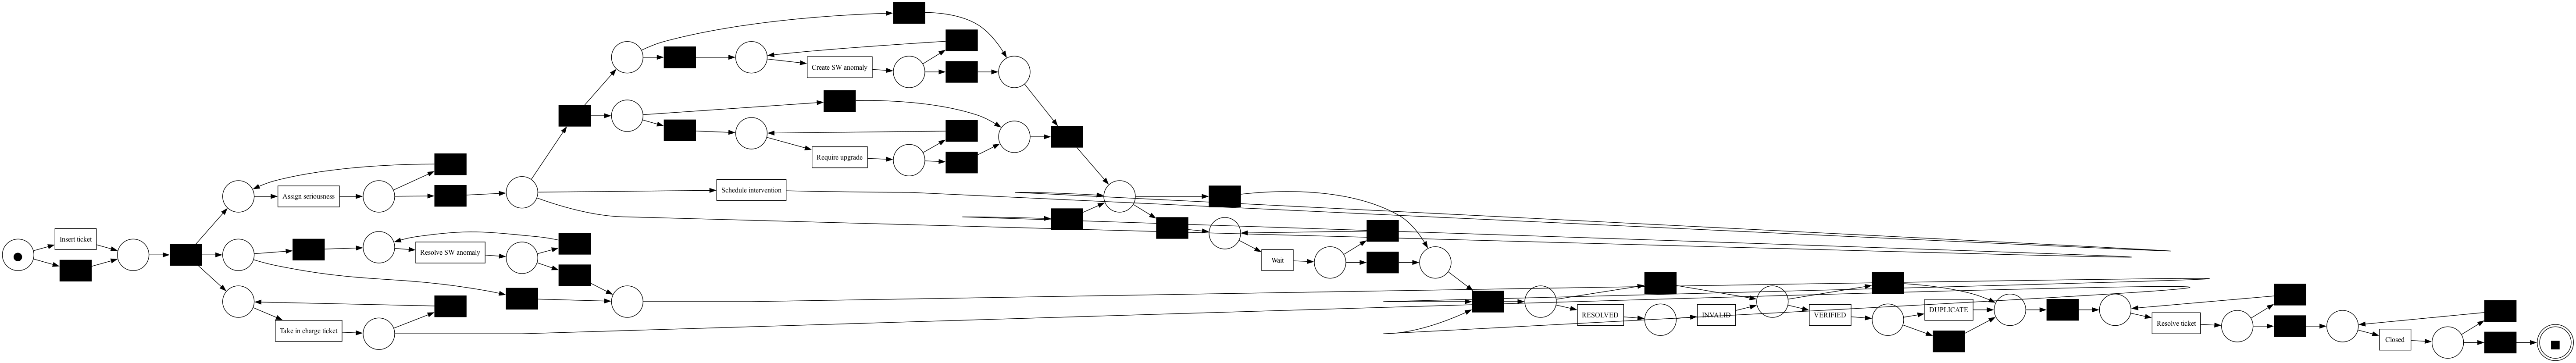

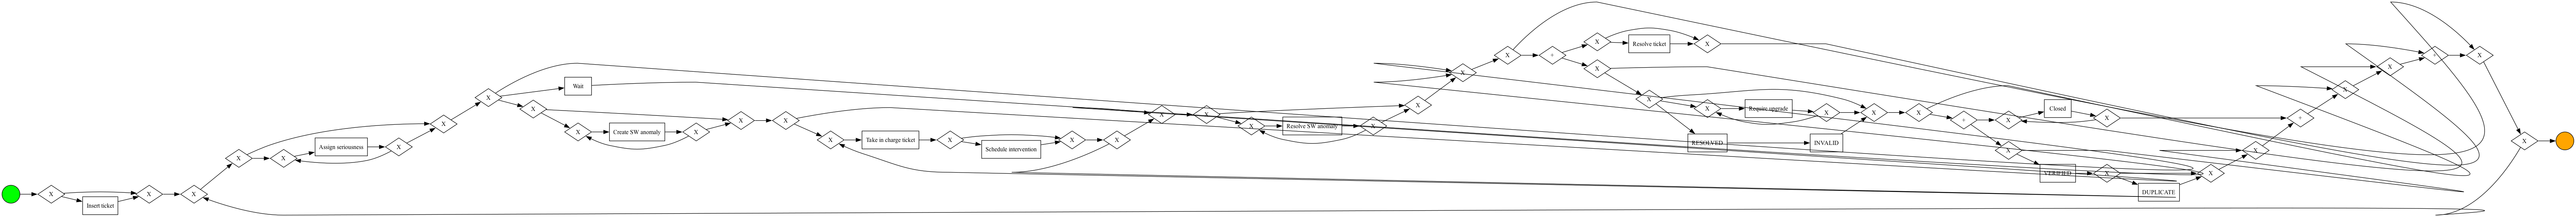

In [3]:
df = pd.read_csv(log_path)

case_col = next(col for col in ("case:concept:name", "CaseID", "Case ID") if col in df.columns)
activity_col = next(col for col in ("concept:name", "Activity") if col in df.columns)
time_col = next(col for col in ("time:timestamp", "CompleteTimestamp", "Complete Timestamp") if col in df.columns)
print(f"Using columns: case={case_col}, activity={activity_col}, time={time_col}")

new_df = pd.DataFrame({
    "case:concept:name": df[case_col].astype(str),
    "concept:name": df[activity_col].astype(str),
    "time:timestamp": pd.to_datetime(df[time_col], errors="coerce"),
})
print(new_df.head(10))

event_log = log_converter.apply(new_df, variant=log_converter.Variants.TO_EVENT_LOG)
print(type(event_log), "traces:", len(event_log))

# Used for both the Petri net and the process tree/BPMN below, so both stay in sync.
noise_threshold = 0.1

net, im, fm = pm4py.discover_petri_net_inductive(
    event_log,
    multi_processing=False,
    noise_threshold=noise_threshold,
    activity_key="concept:name",
    timestamp_key="time:timestamp",
    case_id_key="case:concept:name",
    disable_fallthroughs=False,
)

from IPython.display import Image, display

gviz = pn_visualizer.apply(net, im, fm)
tree = inductive_miner.apply(event_log, parameters={"noise_threshold": noise_threshold})
bpmn = conv.convert_to_bpmn(tree)
gviz_bpmn = bpmn_visualizer.apply(bpmn)

preview_dir = PROJECT_ROOT / "data" / "process_models" / "discovered"
preview_dir.mkdir(parents=True, exist_ok=True)
petri_preview = preview_dir / f"{log_path.stem}_petri.png"
bpmn_preview = preview_dir / f"{log_path.stem}_bpmn.png"
pn_visualizer.save(gviz, str(petri_preview))
bpmn_visualizer.save(gviz_bpmn, str(bpmn_preview))
display(Image(filename=str(petri_preview)))
display(Image(filename=str(bpmn_preview)))

In [ ]:
# NOTE: Discovered models are written to data/process_models/discovered/ only.
# Do NOT write them to data/process_models/<Name>.bpmn -- those are the normative
# To-Be models used by the conformance-checking notebooks (01, 02). A discovered
# model replays the log perfectly by construction and would make every case "safe".
output_dir = PROJECT_ROOT / "data" / "process_models" / "discovered"
output_dir.mkdir(parents=True, exist_ok=True)
model_stem = log_path.stem

bpmn_path = output_dir / f"{model_stem}_inductive.bpmn"
pnml_path = output_dir / f"{model_stem}_inductive.pnml"
petri_png = output_dir / f"{model_stem}_petri.png"
bpmn_png = output_dir / f"{model_stem}_bpmn.png"

pm4py.write_bpmn(bpmn, str(bpmn_path))
pm4py.write_pnml(net, im, fm, str(pnml_path))
pn_visualizer.save(gviz, str(petri_png))
bpmn_visualizer.save(gviz_bpmn, str(bpmn_png))
print("Saved:", bpmn_path)
print("Saved:", pnml_path)
print("Saved:", petri_png)
print("Saved:", bpmn_png)